# Estimation methods for a bivariate normal distribution

## Data creation


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [24]:
np.random.seed(1)

# mu vector
mu = np.random.randn(2)

# Sigma matrix
A = np.random.randn(2, 2)
sigma = np.dot(A, A.T)

var_1 = sigma[0, 0]
var_2 = sigma[1, 1]
cov_12 = sigma[0, 1]

print("--- Vector of means ---")
print(f"mu_1: {mu[0]:.4f}")
print(f"mu_2: {mu[1]:.4f}")

print("\n--- Covariance Matrix ---")
print(f"Variance 1: {var_1:.4f}")
print(f"Variance 2: {var_2:.4f}")
print(f"Covariance: {cov_12:.4f}")

--- Vector of means ---
mu_1: 1.6243
mu_2: -0.6118

--- Covariance Matrix ---
Variance 1: 1.4302
Variance 2: 6.0460
Covariance: 2.0124


We get $\mu = \begin{pmatrix}
1.6243 \\
-0.6118
\end{pmatrix}$ and $\Sigma = \begin{pmatrix}
1.4302 & 2.0124 \\
2.0124 & 6.0460
\end{pmatrix}$

So let´s sample from this distribution:

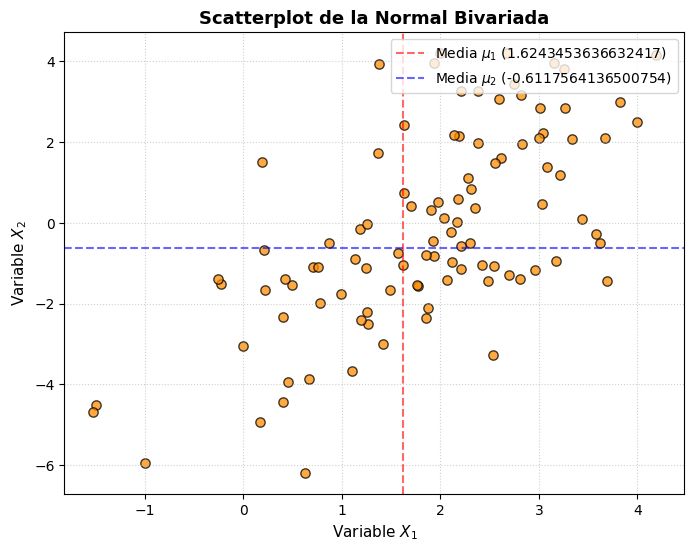

In [30]:

# 3. Generar los 100 datos aleatorios
muestras = np.random.multivariate_normal(mu, sigma, size=100)

# Configurar el gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(
    muestras[:, 0],
    muestras[:, 1],
    color="darkorange",
    alpha=0.75,
    edgecolor="black",
    s=45,
)

# Añadir títulos y etiquetas
plt.title(
    "Scatterplot de la Normal Bivariada", fontsize=13, fontweight="bold"
)
plt.xlabel("Variable $X_1$", fontsize=11)
plt.ylabel("Variable $X_2$", fontsize=11)

# Líneas de referencia para el vector de medias
plt.axvline(
    mu[0],
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Media $\\mu_1$ ({mu[0]})",
)
plt.axhline(
    mu[1],
    color="blue",
    linestyle="--",
    alpha=0.6,
    label=f"Media $\\mu_2$ ({mu[1]})",
)

plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)

# Mostrar la gráfica
plt.show()

# Maximum Likelihood Estimator

In [33]:
n = muestras.shape[0]

# 1. Media MLE
mu_mle = np.mean(muestras, axis=0)

# 2. Matriz de covarianza MLE (ddof=0 para dividir entre n en lugar de n-1)
sigma_mle = np.cov(muestras, rowvar=False, ddof=0)

print("--- Estimadores MLE ---")
print("Vector de medias (mu_mle):\n", mu_mle)
print("\nMatriz de covarianza (sigma_mle):\n", sigma_mle)

--- Estimadores MLE ---
Vector de medias (mu_mle):
 [ 1.87597135 -0.16994411]

Matriz de covarianza (sigma_mle):
 [[1.36150414 1.78864188]
 [1.78864188 5.70560688]]


In [35]:
# 1. Parámetros verdaderos de la normal bivariada
mu_true = np.array([-1.0856, 0.9973])
cov_true = np.array([[2.3490, -2.6513], [-2.6513, 3.0620]])

# 2. Función de Muestreo de Gibbs para Bivariada Normal
def gibbs_bivariate_normal(mu, cov, num_samples=1000, burn_in=200):
    mu1, mu2 = mu[0], mu[1]
    s11, s12 = cov[0, 0], cov[0, 1]
    s22 = cov[1, 1]
    
    # Coeficientes para las condicionales normales unidimensionales
    # Condicional de X1 | X2
    cond1_mean_coef = s12 / s22
    cond1_var = s11 - (s12**2) / s22
    
    # Condicional de X2 | X1
    cond2_mean_coef = s12 / s11
    cond2_var = s22 - (s12**2) / s11
    
    # Inicializar valores
    x1 = mu1
    x2 = mu2
    
    samples = []
    total_iters = num_samples + burn_in
    
    for i in range(total_iters):
        # Muestrear X1 | X2 = x2
        mean_1_given_2 = mu1 + cond1_mean_coef * (x2 - mu2)
        x1 = np.random.normal(mean_1_given_2, np.sqrt(cond1_var))
        
        # Muestrear X2 | X1 = x1
        mean_2_given_1 = mu2 + cond2_mean_coef * (x1 - mu1)
        x2 = np.random.normal(mean_2_given_1, np.sqrt(cond2_var))
        
        # Guardar después del periodo de calentamiento (burn-in)
        if i >= burn_in:
            samples.append([x1, x2])
            
    return np.array(samples)

# Ejecutar el muestreador
np.random.seed(42)
gibbs_samples = gibbs_bivariate_normal(mu_true, cov_true, num_samples=1000)

print("Dimensión de las muestras generadas por Gibbs:", gibbs_samples.shape)
print("\nMedia estimada mediante Gibbs:\n", np.mean(gibbs_samples, axis=0))
print("\nMatriz de covarianza estimada mediante Gibbs:\n", np.cov(gibbs_samples, rowvar=False))

Dimensión de las muestras generadas por Gibbs: (1000, 2)

Media estimada mediante Gibbs:
 [-1.47345816  1.44966754]

Matriz de covarianza estimada mediante Gibbs:
 [[ 1.86870433 -2.09323117]
 [-2.09323117  2.41509318]]
